Early stopping at epoch 36
Train R²: 0.8866
Test  R²: 0.6711
R² Gap (Train - Test): 0.2155
Train RMSE: 80.5835
Test  RMSE: 78.1327
RMSE Gap (Test - Train): -2.4508


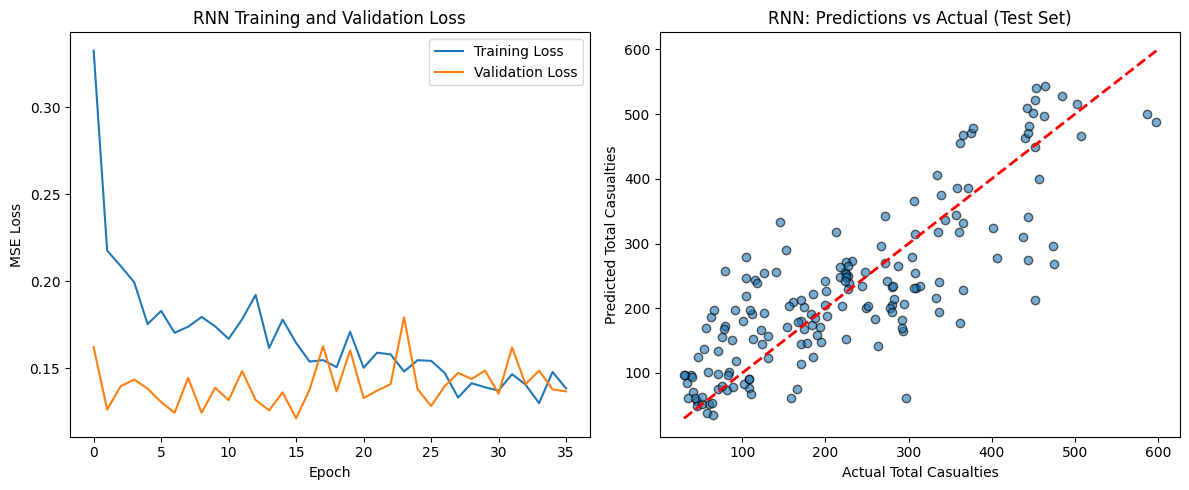

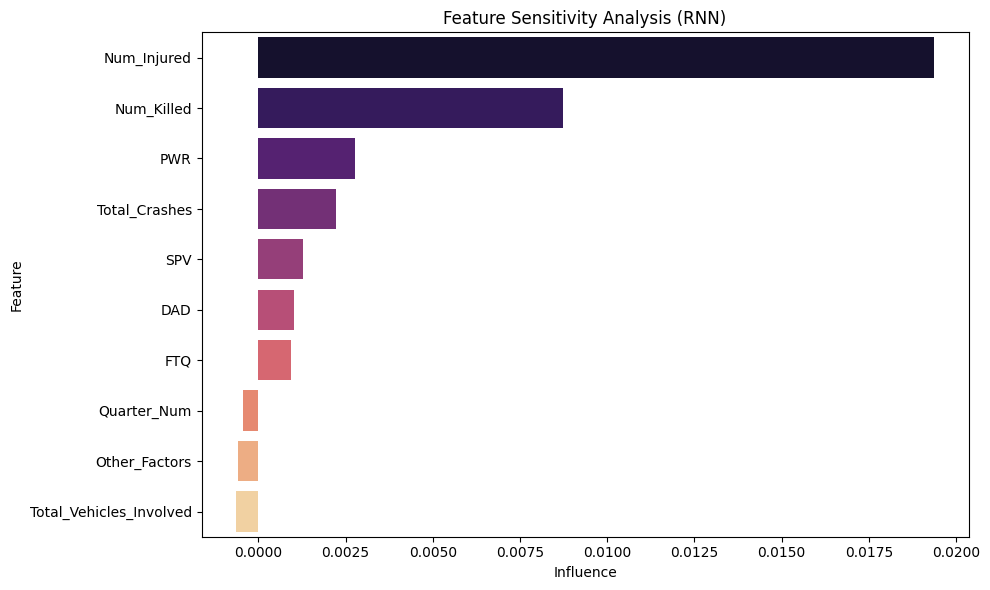

In [2]:
import subprocess
import sys
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch"])
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Augmented Dataset of Nigeria Crash.csv')
df['Quarter_Date'] = pd.to_datetime(df['Quarter_Date'])
df = df.sort_values(['State', 'Quarter_Num'])
feature_cols = [c for c in df.columns if c not in ['Quarter', 'State', 'Quarter_Date', 'State_Encoded', 'Total_Casualties']]
feature_cols = [c for c in feature_cols if df[c].dtype in ['float64', 'int64']]
target_col = 'Total_Casualties'
seq_length = 4
def create_sequences(group):
    group = group.sort_values('Quarter_Num')
    X_seq, y_seq = [], []
    for i in range(len(group) - seq_length):
        X_seq.append(group[feature_cols].values[i:i+seq_length])
        y_seq.append(group[target_col].values[i+seq_length])
    return np.array(X_seq), np.array(y_seq)
all_X, all_y = [], []
for state, group in df.groupby('State'):
    if len(group) > seq_length:
        Xs, ys = create_sequences(group)
        if len(Xs) > 0:
            all_X.append(Xs)
            all_y.append(ys)
X_all = np.vstack(all_X)
y_all = np.hstack(all_y)
X_reshaped = X_all.reshape(X_all.shape[0], seq_length, -1)
scaler_X = StandardScaler()
scaler_y = StandardScaler()
n_samples, seq_len, n_features = X_reshaped.shape
X_flat = X_reshaped.reshape(-1, n_features)
X_scaled_flat = scaler_X.fit_transform(X_flat)
X_scaled = X_scaled_flat.reshape(n_samples, seq_len, n_features)
y_scaled = scaler_y.fit_transform(y_all.reshape(-1, 1)).flatten()
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42, shuffle=False)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class RNNRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RNNRegressor(input_dim=n_features, hidden_dim=128, num_layers=2, dropout=0.3).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
num_epochs = 150
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    train_loss /= len(train_loader.dataset)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
    val_loss /= len(test_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_rnn.pth')
    else:
        patience_counter += 1
        if patience_counter >= 20:
            print(f'Early stopping at epoch {epoch+1}')
            break
model.load_state_dict(torch.load('best_rnn.pth'))
model.eval()
with torch.no_grad():
    train_pred_scaled = model(X_train_tensor.to(device)).cpu().numpy()
    test_pred_scaled = model(X_test_tensor.to(device)).cpu().numpy()
train_pred = scaler_y.inverse_transform(train_pred_scaled).flatten()
test_pred = scaler_y.inverse_transform(test_pred_scaled).flatten()
y_train_orig = scaler_y.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
train_r2 = r2_score(y_train_orig, train_pred)
test_r2 = r2_score(y_test_orig, test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_orig, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_orig, test_pred))
gap_r2 = train_r2 - test_r2
gap_rmse = test_rmse - train_rmse
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")
print(f"R² Gap (Train - Test): {gap_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f"RMSE Gap (Test - Train): {gap_rmse:.4f}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('RNN Training and Validation Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(y_test_orig, test_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', linewidth=2)
plt.xlabel('Actual Total Casualties')
plt.ylabel('Predicted Total Casualties')
plt.title('RNN: Predictions vs Actual (Test Set)')
plt.tight_layout()
plt.savefig('rnn_results.png', dpi=150)
plt.show()
try:
    influence_scores = []
    baseline_pred = test_pred.copy()
    for i in range(min(10, n_features)):
        X_test_pert = X_test_tensor.clone()
        X_test_pert[:, :, i] += 0.1
        with torch.no_grad():
            pert_pred = model(X_test_pert.to(device)).cpu().numpy()
        pert_rmse = np.sqrt(mean_squared_error(y_test_orig, scaler_y.inverse_transform(pert_pred).flatten()))
        influence = (pert_rmse - test_rmse) / test_rmse
        influence_scores.append((feature_cols[i], influence))
    fi_df = pd.DataFrame(influence_scores, columns=['Feature', 'Influence'])
    fi_df = fi_df.sort_values('Influence', ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi_df, x='Influence', y='Feature', palette='magma')
    plt.title('Feature Sensitivity Analysis (RNN)')
    plt.tight_layout()
    plt.savefig('rnn_feature_sensitivity.png', dpi=150)
    plt.show()
except:
    pass